# Feature Engineering - Seleccion de variables

In [1]:
import pandas as pd
import numpy as np

# Configuración de aleatoriedad
np.random.seed(42)
n_samples = 500

# Creación de variables
data = {
    'Metros_Cuadrados': np.random.normal(150, 50, n_samples),
    'N_Habitaciones': np.random.randint(1, 6, n_samples),
    'Antiguedad_Anos': np.random.exponential(10, n_samples),
    'Distancia_Centro_Km': np.random.uniform(1, 20, n_samples),
    'Calidad_Materiales': np.random.choice(['Baja', 'Media', 'Alta', 'Lujo'], n_samples),
    'Tiene_Garaje': np.random.choice([0, 1], n_samples)
}

df = pd.DataFrame(data)

# Crear la variable objetivo (Precio) con ruido y relaciones lógicas
df['Precio'] = (
    df['Metros_Cuadrados'] * 1200 + 
    df['N_Habitaciones'] * 5000 - 
    df['Antiguedad_Anos'] * 800 + 
    np.random.normal(0, 5000, n_samples)
)

# Introducir una variable redundante para Selección de Variables (Multicolinealidad)
df['Pies_Cuadrados'] = df['Metros_Cuadrados'] * 10.76  # Correlación perfecta

In [2]:
#dff = pd.DataFrame(data)

data = {
    'Metros_Cuadrados': np.random.normal(150, 50, n_samples),
    'N_Habitaciones': np.random.randint(1, 6, n_samples),
    'Antiguedad_Anos': np.random.exponential(10, n_samples),
    'Distancia_Centro_Km': np.random.uniform(1, 20, n_samples),
    'Tiene_Garaje': np.random.choice([0, 1], n_samples)
}

dfde = pd.DataFrame(data)


In [3]:
df.head()

,Metros_Cuadrados,N_Habitaciones,Antiguedad_Anos,Distancia_Centro_Km,Calidad_Materiales,Tiene_Garaje,Precio,Pies_Cuadrados
0,174.835708,2,14.621971,15.829985,Lujo,0,200067.472976,1881.232214
1,143.086785,2,5.408842,6.221315,Alta,1,173563.444488,1539.613806
2,182.384427,3,5.470696,16.629672,Media,0,225639.043931,1962.456433
3,226.151493,3,13.378178,9.051027,Alta,1,270979.733671,2433.390063
4,138.292331,5,2.728291,13.683448,Lujo,0,192915.538766,1488.025484


In [4]:
# Transformación Logarítmica para corregir sesgo en Antigüedad
df['Log_Antiguedad'] = np.log1p(df['Antiguedad_Anos'])

# Encoding Ordinal para Calidad
calidad_map = {'Baja': 1, 'Media': 2, 'Alta': 3, 'Lujo': 4}
df['Calidad_Num'] = df['Calidad_Materiales'].map(calidad_map)

In [5]:
df.head()

,Metros_Cuadrados,N_Habitaciones,Antiguedad_Anos,Distancia_Centro_Km,Calidad_Materiales,Tiene_Garaje,Precio,Pies_Cuadrados,Log_Antiguedad,Calidad_Num
0,174.835708,2,14.621971,15.829985,Lujo,0,200067.472976,1881.232214,2.748678,4
1,143.086785,2,5.408842,6.221315,Alta,1,173563.444488,1539.613806,1.857679,3
2,182.384427,3,5.470696,16.629672,Media,0,225639.043931,1962.456433,1.867284,2
3,226.151493,3,13.378178,9.051027,Alta,1,270979.733671,2433.390063,2.665712,3
4,138.292331,5,2.728291,13.683448,Lujo,0,192915.538766,1488.025484,1.315950,4


Métodos Wrapper (Basados en Búsqueda)
Evalúan subconjuntos de variables entrenando el modelo repetidamente.

RFE (Recursive Feature Elimination): Entrena, mira la importancia, elimina la peor, y repite.

Pros: Muy preciso. Contras: Computacionalmente carísimo.

Métodos Embedded (Integrados)
El modelo mismo decide qué importa durante el entrenamiento. El ejemplo rey es la Regresión Lineal.

Concepto clave: Lasso añade una penalización que fuerza a los coeficientes de las variables menos importantes a ser exactamente cero.

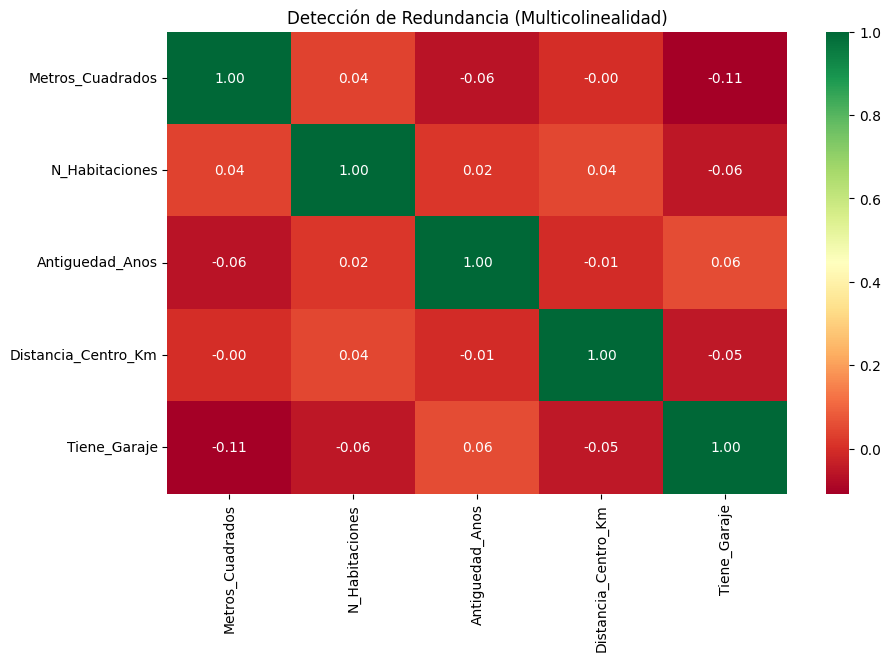

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(dfde.corr(), annot=True, cmap='RdYlGn', fmt=".2f")
plt.title("Detección de Redundancia (Multicolinealidad)")
plt.show()

# Para Investigar

### Reducción de Dimensionalidad: PCA
### A diferencia de la selección (donde borramos columnas), el PCA (Análisis de Componentes Principales) combina las columnas existentes en "Super Variables" llamadas Componentes Principales.

### PC1: Captura la mayor varianza posible.

### C2: Captura la varianza restante ortogonal a PC1.

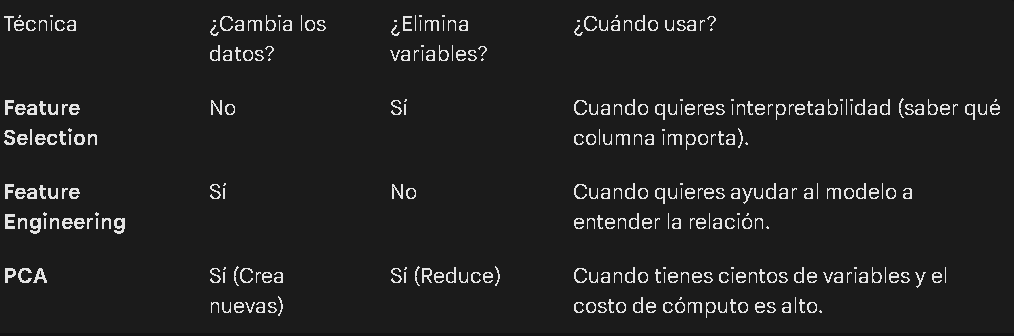

## Limpieza: ¿Hay nulos? ¿Hay variables de texto que el modelo no entiende? (Encoding).

## Tratamiento: ¿Están los datos en la misma escala? (Scaling).

## Filtrado: ¿Tengo variables que dicen lo mismo? (Correlación).

## Selección: ¿Cuáles son las 5 variables que explican el 90% del precio? (RFE o Feature Importance).

## Investigar como y donde es mas recomendable utilizar cada uno de estoy conceptos en la creacion de un modelo de ML

In [7]:
#Detección de Data Leakage (Fuga de Datos)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['Precio', 'Calidad_Materiales', 'Antiguedad_Anos'])  # Excluir la variable objetivo y categórica original
y = df['Precio']

# Dividir primero
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ajustar el escalador SOLO con el train
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Aplicar (transform) al test con la media del train
X_test_scaled = scaler.transform(X_test)

Text(0.5, 1.0, 'Comparación: Con vs Sin Outliers')

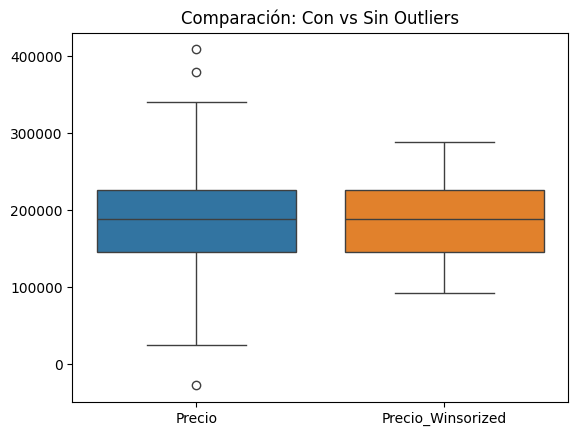

In [8]:
#Manejo de Outliers (Winsorizing)

from scipy.stats.mstats import winsorize

# Limitamos los valores al percentil 5 y 95
# Las casas extremadamente caras se igualan al valor del percentil 95
df['Precio_Winsorized'] = winsorize(df['Precio'], limits=[0.05, 0.05])

import seaborn as sns
sns.boxplot(data=df[['Precio', 'Precio_Winsorized']])
plt.title("Comparación: Con vs Sin Outliers")

C:\Users\danie\AppData\Local\Temp\ipykernel_34036\3576819998.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Categoria_Edad')['Precio'].mean().plot(kind='bar')


<Axes: xlabel='Categoria_Edad'>

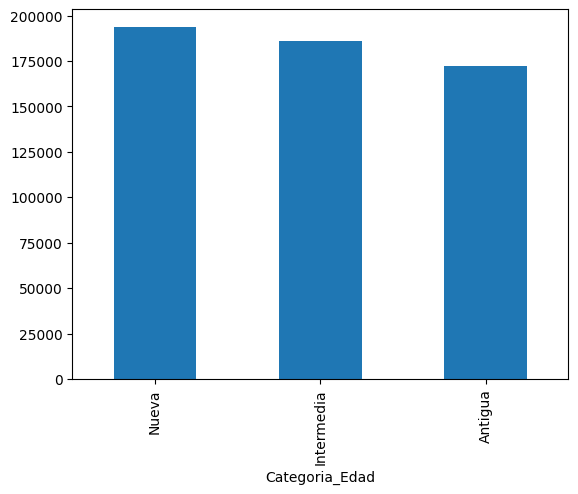

In [9]:
#Binning (Discretización)

# Crear categorías basadas en rangos lógicos
bins = [0, 5, 20, 100]
labels = ['Nueva', 'Intermedia', 'Antigua']
df['Categoria_Edad'] = pd.cut(df['Antiguedad_Anos'], bins=bins, labels=labels)

# Ver cómo influye la categoría en el precio promedio
df.groupby('Categoria_Edad')['Precio'].mean().plot(kind='bar')

Text(0.5, 0, 'Caída en el desempeño del modelo al desordenar la variable')

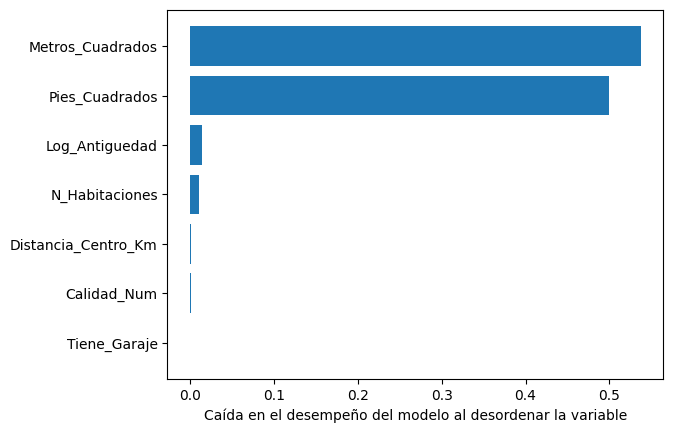

In [10]:
#Importancia por Permutación (Model Agnostic)

from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor().fit(X_train, y_train)
result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)

# Graficar
sorted_idx = result.importances_mean.argsort()
plt.barh(X.columns[sorted_idx], result.importances_mean[sorted_idx])
plt.xlabel("Caída en el desempeño del modelo al desordenar la variable")

In [11]:
#Ingeniería de Tiempo (Extracción de Características)

# Simulando una columna de fecha de venta
df['Fecha_Venta'] = pd.to_datetime(['2023-01-15', '2023-06-20', '2023-12-05'] * 166 + ['2023-01-01'] * 2)

# Extraer el mes (Estacionalidad)
df['Mes_Venta'] = df['Fecha_Venta'].dt.month

# Extraer si fue en fin de semana (Día 5 y 6)
df['Vendido_FinSemana'] = df['Fecha_Venta'].dt.dayofweek.isin([5, 6]).astype(int)

In [12]:
df.head()

,Metros_Cuadrados,N_Habitaciones,Antiguedad_Anos,Distancia_Centro_Km,Calidad_Materiales,Tiene_Garaje,Precio,Pies_Cuadrados,Log_Antiguedad,Calidad_Num,Precio_Winsorized,Categoria_Edad,Fecha_Venta,Mes_Venta,Vendido_FinSemana
0,174.835708,2,14.621971,15.829985,Lujo,0,200067.472976,1881.232214,2.748678,4,200067.472976,Intermedia,2023-01-15,1,1
1,143.086785,2,5.408842,6.221315,Alta,1,173563.444488,1539.613806,1.857679,3,173563.444488,Intermedia,2023-06-20,6,0
2,182.384427,3,5.470696,16.629672,Media,0,225639.043931,1962.456433,1.867284,2,225639.043931,Intermedia,2023-12-05,12,0
3,226.151493,3,13.378178,9.051027,Alta,1,270979.733671,2433.390063,2.665712,3,270979.733671,Intermedia,2023-01-15,1,1
4,138.292331,5,2.728291,13.683448,Lujo,0,192915.538766,1488.025484,1.315950,4,192915.538766,Nueva,2023-06-20,6,0


In [13]:
# Selección de Variables con Lasso (L1)

from sklearn.linear_model import Lasso

lasso = Lasso(alpha=100) # Alfa controla qué tan agresiva es la eliminación
lasso.fit(X_train_scaled, y_train)

# Mostrar coeficientes
coeficientes = pd.Series(lasso.coef_, index=X.columns)
print(coeficientes[coeficientes == 0]) # Variables eliminadas

Series([], dtype: float64)
